# **Data Discretizaiton and Binning**

Data discretization and binning are techniques used in data preprocessing to convert continuous variables into discrete categories or bins. This process can help improve the performance of machine learning algorithms, especially those that work better with categorical data.It can also help to improve interpretability and handle outliers more effectively.

In [12]:
# import necessary libraries
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

In [13]:
# Load the dataset
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# check the missing values in the df dataset
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
# impute the mising values in the df dataset colomn `age` and `embarked`.
df['age'].fillna(df['age'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8188\2870809410.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8188\2870809410.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

<Axes: xlabel='age', ylabel='Count'>

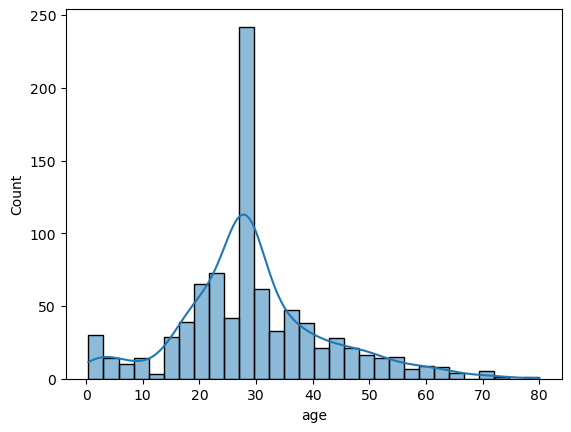

In [19]:
# histogram of the age colomn
sns.histplot(df['age'],kde=True)

In [28]:
# Age Discretization using KBinsDiscretizer
est=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='uniform')
df['age_binned']=est.fit_transform(df[['age']])
df[['age','age_binned']].head(10)

,age,age_binned
0,22.0,1.0
1,38.0,2.0
2,26.0,1.0
3,35.0,2.0
4,35.0,2.0
5,28.0,1.0
6,54.0,3.0
7,2.0,0.0
8,27.0,1.0
9,14.0,0.0


<Axes: xlabel='age', ylabel='Count'>

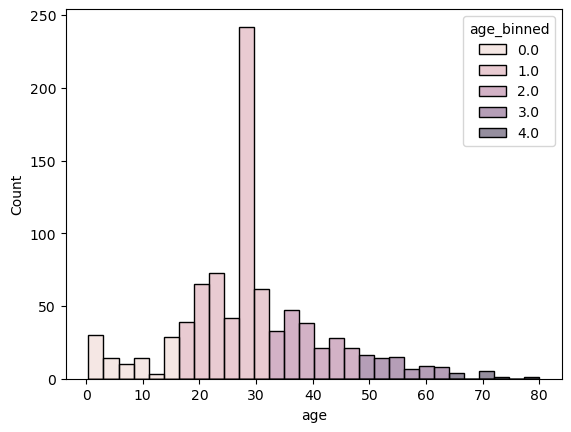

In [29]:
# histogram of the age colomn
sns.histplot(df,x='age',hue='age_binned')

In [30]:
# do the manual bining using pandas on the df dataset
bins=[0,12,20,40,60,80]
labels=['Child','Teenager','Adult','Mid-Age','Senior']
df['age_binned_manual']=pd.cut(df['age'],bins=bins,labels=labels)
df[['age','age_binned_manual']].head(10)


,age,age_binned_manual
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Adult
6,54.0,Mid-Age
7,2.0,Child
8,27.0,Adult
9,14.0,Teenager


<Axes: xlabel='age', ylabel='Count'>

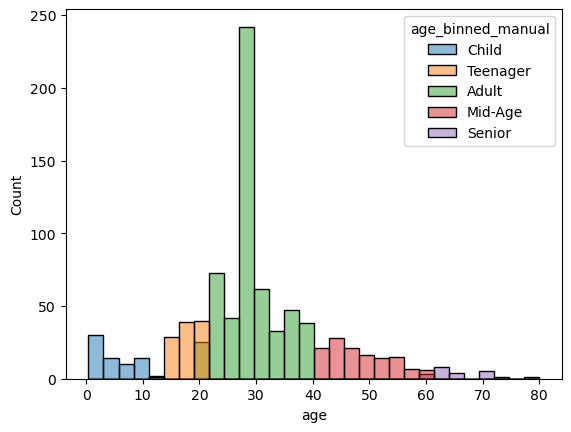

In [31]:
sns.histplot(df,x='age',hue='age_binned_manual')